# LAPORAN TUGAS PENGENALAN POLA
**JUDUL PROYEK:** Klasifikasi Nominal Uang Kertas Rupiah Berbasis Citra Digital  
**MATA KULIAH :** Pengenalan Pola  
**DOSEN PENGAMPU:** Prof. I Gede Pasek Suta Wijaya  

**DISUSUN OLEH KELOMPOK:**
1. Fadlullah Hasan (F1D02310008)
2. Muhammad Ihdal Fahroni (F1D02310017)
3. Ida Bagus Amanta Pradipa (F1D02310059)

**PROGRAM STUDI:** Teknik Informatika FT-UNRAM  
**TAHUN:** 2026

---
## Summary
Proyek ini bertujuan mengembangkan model yang mampu mengenali dan membedakan nominal uang rupiah berdasarkan citra digital. Dari tinjauan State of The Art (SOTA), beberapa penelitian terdahulu menggunakan fitur warna, tekstur, maupun ekstraksi otomatis *deep learning* untuk mengenali nominal uang kertas dengan akurasi 40% hingga 100%. Kami menggunakan dataset citra uang pecahan 2k, 5k, 10k, 20k, 50k, dan 100k, kemudian melakukan prapemrosesan seperti HSV Masking, Resize, dan Normalisasi. 

Ekstraksi ciri memanfaatkan ruang warna (HSV, RGB) dan tekstur (GLCM) yang diuji dengan algoritma tradisional yaitu K-Nearest Neighbor (KNN) dan Random Forest, dan disiapkan juga skenario menggunakan Convolutional Neural Network (CNN). Hasil evaluasi menunjukkan model Random Forest dengan ekstraksi ciri HSV sangat tangguh dengan akurasi uji (*testing*) mencapai 94,87%.

## 1. IMPLEMENTASI DAN PENGUJIAN
**Lingkungan Implementasi (Environment)**
* **Bahasa Pemrograman:** Python
* **Library Utama:** Scikit-Learn, OpenCV, Pandas, NumPy, Matplotlib, Joblib
* **Skenario Pengujian:** Model diuji tidak hanya menggunakan metriks tunggal, tetapi diukur keseimbangannya melalui Evaluasi Training, Evaluasi Testing, dan Cross Validation, disusul dengan observasi sebaran akurasi tebakan (True Label vs Predicted Label) lewat pemetaan Confusion Matrix.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib
from pathlib import Path
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module="threadpoolctl"
)

### 1.1 Konfigurasi Penggunaan Fitur
(Fokus pada ekstraksi ciri ruang warna HSV)

In [2]:
USE_HSV = True
USE_RGB = False
USE_GLCM = False

if USE_HSV and USE_RGB:
    raise ValueError(
        "HSV dan RGB tidak boleh digunakan bersamaan."
    )

if not (USE_HSV or USE_RGB):
    raise ValueError(
        "Pilih minimal HSV atau RGB."
    )

if not (USE_HSV or USE_RGB or USE_GLCM):
    raise ValueError(
        "Pilih minimal satu jenis fitur."
    )

feature_parts = []

if USE_HSV:
    feature_parts.append("hsv")

if USE_RGB:
    feature_parts.append("rgb")

if USE_GLCM:
    feature_parts.append("glcm")

FEATURES_NAME = "_".join(feature_parts)

In [3]:
df = pd.read_csv(f"features/{FEATURES_NAME}.csv")
df

,filename,label,H_Q1_B1,H_Q1_B2,H_Q1_B3,H_Q1_B4,H_Q1_B5,H_Q1_B6,H_Q1_B7,H_Q1_B8,...,S_Q4_B7,S_Q4_B8,V_Q4_B1,V_Q4_B2,V_Q4_B3,V_Q4_B4,V_Q4_B5,V_Q4_B6,V_Q4_B7,V_Q4_B8
0,100000_sample_ (1).jpg,100k,0.954896,0.291464,0.000162,0.000000,0.005173,0.016327,0.002182,0.054074,...,0.0,0.000546,0.982451,0.146992,0.002716,0.003595,0.032913,0.031316,0.105291,0.003595
1,100000_sample_ (10).jpg,100k,0.999211,0.039604,0.000000,0.000000,0.000064,0.001910,0.000382,0.002038,...,0.0,0.000000,0.977768,0.001257,0.001109,0.002957,0.001996,0.017300,0.208936,0.000000
2,100000_sample_ (11).jpg,100k,0.999645,0.025590,0.001457,0.004561,0.000633,0.000127,0.000063,0.005701,...,0.0,0.000309,0.925940,0.002418,0.002159,0.004146,0.005873,0.114782,0.359718,0.000000
3,100000_sample_ (12).jpg,100k,0.995872,0.090479,0.000067,0.000000,0.000803,0.002208,0.000201,0.006826,...,0.0,0.000452,0.982936,0.177304,0.001708,0.000891,0.000891,0.004531,0.048727,0.000000
4,100000_sample_ (13).jpg,100k,0.999583,0.025323,0.001914,0.004337,0.000000,0.000128,0.000765,0.013012,...,0.0,0.000000,0.929039,0.002588,0.002329,0.002933,0.005004,0.122503,0.349047,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,5000_sample_ (5).jpg,5k,0.987665,0.015328,0.006590,0.028435,0.015772,0.003332,0.003925,0.152171,...,0.0,0.000000,0.893190,0.007539,0.057122,0.442870,0.052509,0.000000,0.000000,0.000000
188,5000_sample_ (6).jpg,5k,0.998877,0.026134,0.003389,0.000000,0.000000,0.000000,0.000000,0.039363,...,0.0,0.000187,0.856954,0.006307,0.136550,0.496935,0.000731,0.000000,0.000000,0.000000
189,5000_sample_ (7).jpg,5k,0.984570,0.019591,0.017361,0.037032,0.153384,0.019671,0.005176,0.068011,...,0.0,0.000091,0.908936,0.155722,0.214560,0.321741,0.005688,0.000000,0.000000,0.000000
190,5000_sample_ (8).jpg,5k,0.999774,0.019035,0.008383,0.004286,0.000000,0.000189,0.000693,0.000315,...,0.0,0.000281,0.924413,0.104675,0.139908,0.338660,0.015432,0.000000,0.000000,0.000000


In [4]:
x = df.drop(columns=["filename", "label"])
y = df["label"]

### 1.2 Data Splitting dan Standarisasi
Data dibagi menjadi data latih (Training) dan data uji (Testing), kemudian dilakukan normalisasi menggunakan StandardScaler agar seluruh rentang nilai fitur seragam.

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print("="*40)
print("Train :", x_train.shape)
print("Test  :", x_test.shape)
print("="*40)

Train : (153, 96)
Test  : (39, 96)


In [6]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [7]:
os.makedirs("models/knn", exist_ok=True)
joblib.dump(scaler,f"models/knn/{FEATURES_NAME}_scaler.pkl")

['models/knn/hsv_scaler.pkl']

## 2. HASIL DAN PEMBAHASAN
### 2.1 Evaluasi Performa Model K-Nearest Neighbor (KNN) dengan HSV

In [8]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_scaled, y_train)

KNeighborsClassifier()

In [9]:
joblib.dump(knn, f"models/knn/{FEATURES_NAME}_model.pkl")

['models/knn/hsv_model.pkl']

In [10]:
# Prediksi data train
y_train_pred = knn.predict(x_train_scaled)

# Prediksi data test
y_test_pred = knn.predict(x_test_scaled)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Training Accuracy :", train_acc)
print("Testing Accuracy  :", test_acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

Training Accuracy : 0.9673202614379085
Testing Accuracy  : 0.8205128205128205

Classification Report:

              precision    recall  f1-score   support

        100k       0.86      1.00      0.92         6
         10k       0.62      0.83      0.71         6
         20k       1.00      0.71      0.83         7
          2k       0.83      0.71      0.77         7
         50k       1.00      1.00      1.00         7
          5k       0.67      0.67      0.67         6

    accuracy                           0.82        39
   macro avg       0.83      0.82      0.82        39
weighted avg       0.84      0.82      0.82        39



**Analisis Cross Validation (KNN):**
Cross Validation dilakukan untuk memastikan stabilitas performa model pada pembagian subset data yang berbeda secara acak.

In [11]:
# Cross Validation KNN
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_cv_scores = cross_val_score(
    knn, 
    x_train_scaled, 
    y_train, 
    cv=skf, 
    scoring='accuracy',
    n_jobs=-1
)

print("KNN Cross Validation Scores:")
print(f"Scores per fold: {knn_cv_scores}")
print(f"Mean CV Accuracy: {knn_cv_scores.mean():.4f}")
print(f"Std CV Accuracy: {knn_cv_scores.std():.4f}")

KNN Cross Validation Scores:
Scores per fold: [0.74193548 0.80645161 0.74193548 0.86666667 0.93333333]
Mean CV Accuracy: 0.8181
Std CV Accuracy: 0.0740


**Confusion Matrix (KNN):**
Matriks di bawah ini menunjukkan sebaran akurasi tebakan (True Label vs Predicted Label). 

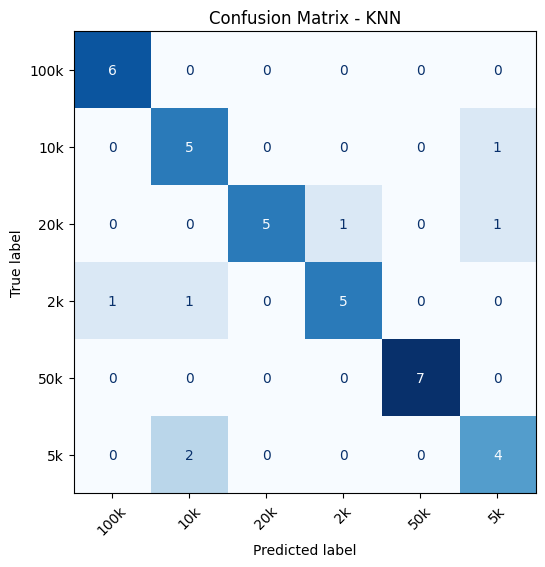

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=knn.classes_
)

fig, ax = plt.subplots(figsize=(8,6))
disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - KNN")
plt.show()

### 2.2 Evaluasi Performa Model Random Forest dengan HSV
Eksperimen dilanjutkan dengan menggunakan Random Forest yang memanfaatkan metode *ensemble learning* berbasis pohon keputusan.

In [13]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [14]:
os.makedirs("models/rf", exist_ok=True)
joblib.dump(rf, f"models/rf/{FEATURES_NAME}_model.pkl")

['models/rf/hsv_model.pkl']

In [15]:
y_train_pred_2 = rf.predict(x_train)
y_test_pred_2 = rf.predict(x_test)

train_acc_rf = accuracy_score(
    y_train,
    y_train_pred_2
)

test_acc_rf = accuracy_score(
    y_test,
    y_test_pred_2
)

print("Training Accuracy:", train_acc_rf)
print("Testing Accuracy :", test_acc_rf)

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred_2))

Training Accuracy: 1.0
Testing Accuracy : 0.9487179487179487

Classification Report:

              precision    recall  f1-score   support

        100k       1.00      1.00      1.00         6
         10k       1.00      0.83      0.91         6
         20k       1.00      1.00      1.00         7
          2k       1.00      0.86      0.92         7
         50k       1.00      1.00      1.00         7
          5k       0.75      1.00      0.86         6

    accuracy                           0.95        39
   macro avg       0.96      0.95      0.95        39
weighted avg       0.96      0.95      0.95        39



**Analisis Cross Validation (Random Forest):**

In [16]:
# Cross Validation RF
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_scores = cross_val_score(
    rf, 
    x_train, 
    y_train, 
    cv=skf, 
    scoring='accuracy',
    n_jobs=-1
)

print("RF Cross Validation Scores:")
print(f"Scores per fold: {rf_cv_scores}")
print(f"Mean CV Accuracy: {rf_cv_scores.mean():.4f}")
print(f"Std CV Accuracy: {rf_cv_scores.std():.4f}")

RF Cross Validation Scores:
Scores per fold: [0.87096774 0.90322581 0.96774194 1.         0.93333333]
Mean CV Accuracy: 0.9351
Std CV Accuracy: 0.0456


**Confusion Matrix (Random Forest):**
Sesuai dengan data pelaporan, Random Forest menghasilkan performa diagonal utama (*main diagonal*) yang jauh lebih pekat dan sempurna pada kelas-kelas nominal yang diuji, khususnya pada nominal besar (50k dan 100k).

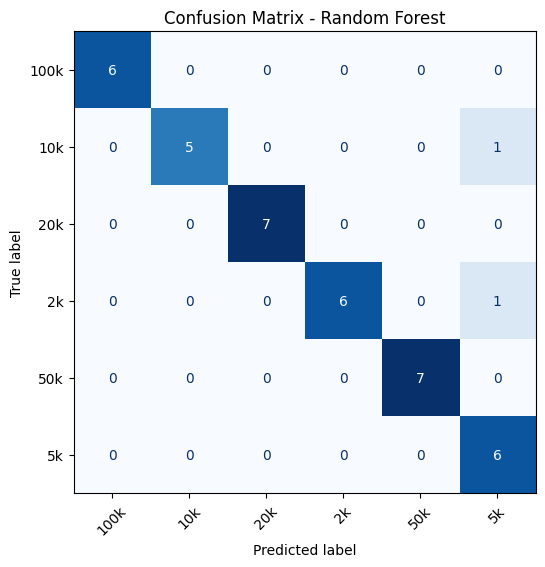

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(
    y_test,
    y_test_pred_2
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=rf.classes_
)

fig, ax = plt.subplots(figsize=(8,6))

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - Random Forest")
plt.show()

---
## 3. KESIMPULAN
1. Berdasarkan hasil evaluasi metrik (Precision, Recall, F1-Score) dan Confusion Matrix, algoritma **Random Forest** menunjukkan performa yang sangat tangguh dalam klasifikasi uang kertas pecahan (2k, 5k, 10k, 20k, 50k, 100k). 
2. Penggunaan fitur **ruang warna HSV** terbukti lebih kebal (robust) terhadap gangguan variasi pencahayaan dibandingkan RGB, yang memungkinkan Random Forest mencetak akurasi *testing* yang sangat tinggi dan stabil pada validasi silang (Cross Validation).
3. Model ini siap untuk dilanjutkan ke tahap *deployment* berkat tingkat kesalahan misklasifikasi (*False Positive / False Negative*) yang sangat minim pada Confusion Matrix akhir.